# JumpGuard AI - Core Data Framework Demo

This notebook demonstrates the public Prompt 02 API. It does not access raw MATLAB structures; all work flows through `Dataset`, `Participant`, and `Trial`.

## 1. Setup

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src import Dataset, validate_dataset
from src.visualization import (
    plot_dataset_summary,
    plot_joint_angle,
    plot_participant,
    plot_trial,
)

MAT_PATH = PROJECT_ROOT / 'data' / 'sample' / 'DJ.mat'

## 2. Load Through the Single Public API

`Dataset.load()` resolves the label and metadata workbooks, parses the MAT file, constructs clean domain objects, and validates the result.

In [2]:
dataset = Dataset.load(MAT_PATH)
dataset.summary()

{'participants': 43,
 'participant_ids': [1,
  2,
  3,
  4,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44],
 'total_trial_slots': 258,
 'valid_trials': 249,
 'empty_trials': 9,
 'joint_angle_labels': 44,
 'frame_min': 842,
 'frame_max': 2280,
 'frame_mean': 1401.120481927711,
 'frame_median': 1395.0}

## 3. Inspect a Participant

In [3]:
participant = dataset.get_participant('sub01')
participant.summary()

{'participant_id': 1,
 'total_trial_slots': 6,
 'valid_trials': 6,
 'empty_trials': 0,
 'frame_count': 6864,
 'metadata': {'jump': 6,
  'subject': 1,
  'group': 1,
  'gender': 1,
  'leg_dominance': 1,
  'fatigued_leg': 2,
  'acl_injured_leg': 0}}

In [4]:
[(trial.slot, trial.name, trial.condition, trial.is_empty) for trial in participant.list_trials(include_empty=True)]

[(1, 'DJ_t1', 'nonfatigued', False),
 (2, 'DJ_t2', 'nonfatigued', False),
 (3, 'DJ_t3', 'nonfatigued', False),
 (4, 'f_DJ_t1', 'fatigued', False),
 (5, 'f_DJ_t2', 'fatigued', False),
 (6, 'f_DJ_t3', 'fatigued', False)]

## 4. Inspect a Trial and Access Angles Semantically

In [5]:
trial = participant.get_trial('DJ_t1')
trial.summary()

{'participant_id': 1,
 'slot': 1,
 'name': 'DJ_t1',
 'condition': 'nonfatigued',
 'is_empty': False,
 'missing_reason': None,
 'frames': 1175,
 'joint_angle_columns': 44,
 'event_count': 4,
 'marker_count': 60}

In [6]:
right_knee = trial.get_joint_angle('knee_angle_r')
{
    'shape': right_knee.shape,
    'first_five_values': right_knee[:5].tolist(),
    'available_label_count': len(trial.joint_angle_labels),
}

{'shape': (1175,),
 'first_five_values': [4.44418371,
  4.39959804,
  4.49200571,
  4.3919437,
  4.4693091],
 'available_label_count': 44}

## 5. Validate

The canonical data has nine metadata-documented empty slots. These are warnings, not corruption errors.

In [7]:
validation_report = validate_dataset(dataset)
validation_report.to_dict()

{'is_valid': True,
 'error_count': 0,
 'warning_count': 9,
 'issues': [{'severity': 'warning',
   'code': 'empty_trial',
   'path': 'participant[32].trial[4]',
   'message': 'Trial is empty: no c3d file; excessive marker movement',
   'suggested_fix': 'Preserve the empty slot and exclude it from numeric analysis.'},
  {'severity': 'warning',
   'code': 'empty_trial',
   'path': 'participant[32].trial[5]',
   'message': 'Trial is empty: no c3d file; excessive marker movement',
   'suggested_fix': 'Preserve the empty slot and exclude it from numeric analysis.'},
  {'severity': 'warning',
   'code': 'empty_trial',
   'path': 'participant[32].trial[6]',
   'message': 'Trial is empty: no c3d file; excessive marker movement',
   'suggested_fix': 'Preserve the empty slot and exclude it from numeric analysis.'},
  {'severity': 'warning',
   'code': 'empty_trial',
   'path': 'participant[44].trial[1]',
   'message': 'Trial is empty: no c3d file; pain reported',
   'suggested_fix': 'Preserve the

## 6. Reusable Visualizations

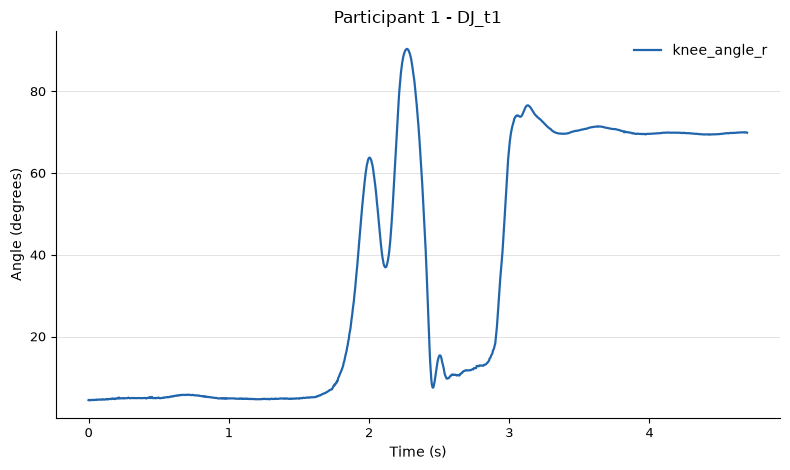

In [8]:
plot_joint_angle(trial, 'knee_angle_r');

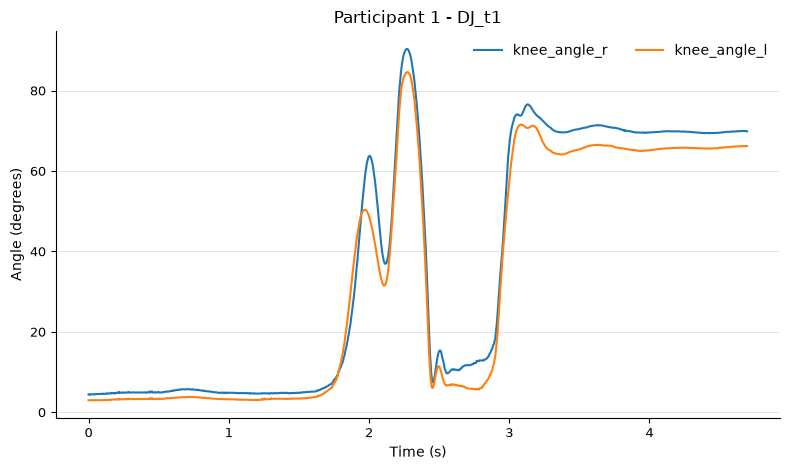

In [9]:
plot_trial(trial, ('knee_angle_r', 'knee_angle_l'));

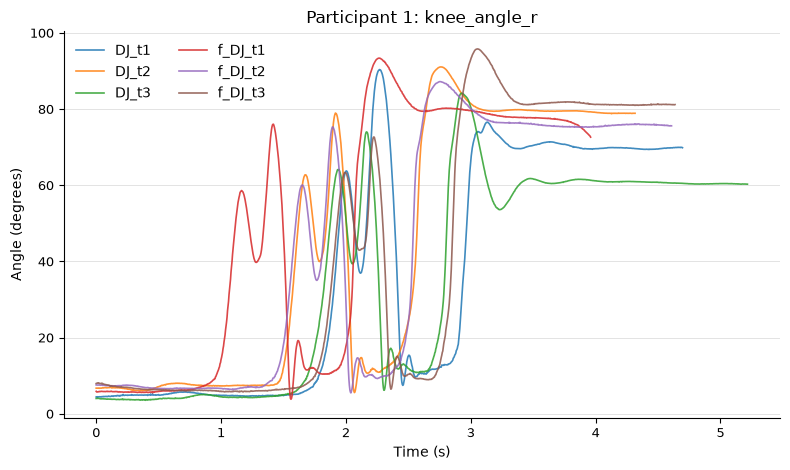

In [10]:
plot_participant(participant, 'knee_angle_r');

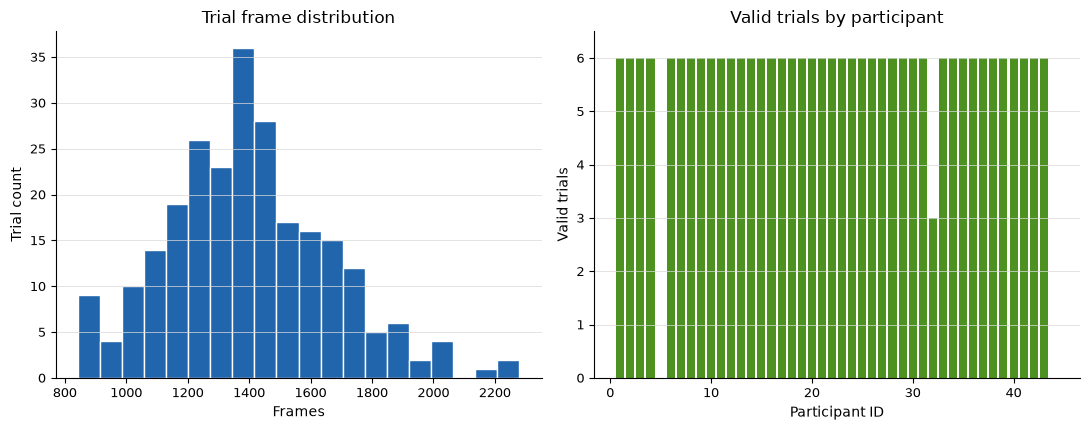

In [11]:
plot_dataset_summary(dataset);

## 7. Missing-Trial Preservation

Missing slots remain addressable and carry their documented reason.

In [12]:
missing_trial = dataset.get_participant(32).get_trial(4)
missing_trial.summary()

{'participant_id': 32,
 'slot': 4,
 'name': 'f_DJ_t1',
 'condition': 'fatigued',
 'is_empty': True,
 'missing_reason': 'no c3d file; excessive marker movement',
 'frames': 0,
 'joint_angle_columns': 0,
 'event_count': 0,
 'marker_count': 0}